In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
from matplotlib.transforms import Affine2D
from scipy import stats

# Apply publication style
pubstyle = False

# Configure matplotlib
if pubstyle:
    plt.style.use('onerule.mplstyle')
    
protocol_labels = {"mrk97_01": "L5 to L5\n2 Hz, 5 ms",
                   "mrk97_02": "L5 to L5\n5 Hz, 5 ms",
                   "mrk97_07": "L5 to L5\n10 Hz, 10 ms",
                   "mrk97_08": "L5 to L5\n10 Hz, -10 ms",
                   "sjh06_02": "L2/3 to L5\n50 Hz, 10 ms"}

# Population analysis

In [2]:
# Load in vitro data
invitro_res = pd.read_csv('data/invitro/paired_recordings.csv')
invitro_res['std_epsp_ratio'] = invitro_res['sem_epsp_ratio'] * np.sqrt(invitro_res['sample_size'])
for key, label in protocol_labels.items():
    invitro_res.loc[invitro_res.protocol_id == key, 'label'] = label
invitro_res

,protocol_id,pre_mtype,post_mtype,area,animal,age,frequency_train,dt_train,n_stimuli_train,n_sweep,period_sweep,mean_epsp_ratio,sem_epsp_ratio,sample_size,reference,notes,std_epsp_ratio,label
0,mrk97_01,L5TTPC,L5TTPC,SSC,rat,P14 - P16,2.0,5,5,10,4,0.988600,0.040000,2,Markram et al. 1997,Record digitized from paper.,0.056569,"L5 to L5\n2 Hz, 5 ms"
1,mrk97_02,L5TTPC,L5TTPC,SSC,rat,P14 - P16,5.0,5,5,10,4,1.016100,0.072700,5,Markram et al. 1997,Record digitized from paper.,0.162562,"L5 to L5\n5 Hz, 5 ms"
2,mrk97_03,L5TTPC,L5TTPC,SSC,rat,P14 - P16,10.0,5,5,10,4,1.203800,0.064400,9,Markram et al. 1997,Record digitized from paper.,0.193200,NaN
3,mrk97_04,L5TTPC,L5TTPC,SSC,rat,P14 - P16,20.0,5,5,10,4,1.368700,0.090900,11,Markram et al. 1997,Record digitized from paper.,0.301481,NaN
4,mrk97_05,L5TTPC,L5TTPC,SSC,rat,P14 - P16,30.0,5,5,10,4,1.423900,0.074500,3,Markram et al. 1997,Record digitized from paper.,0.129038,NaN
5,mrk97_06,L5TTPC,L5TTPC,SSC,rat,P14 - P16,40.0,5,5,10,4,1.500800,0.120000,4,Markram et al. 1997,Record digitized from paper.,0.240000,NaN
6,mrk97_07,L5TTPC,L5TTPC,SSC,rat,P14 - P16,10.0,10,5,10,4,1.201300,0.062600,6,Markram et al. 1997,Record digitized from paper. AP train repeated...,0.153338,"L5 to L5\n10 Hz, 10 ms"
7,mrk97_08,L5TTPC,L5TTPC,SSC,rat,P14 - P16,10.0,-10,5,10,4,0.792200,0.025900,6,Markram et al. 1997,Record digitized from paper. AP train repeated...,0.063442,"L5 to L5\n10 Hz, -10 ms"
8,egg99_01,L23PC,L23PC,SSC (barrel),rat,P12 - P14,20.0,10,5,10,10,1.299000,0.082000,12,Egger et al. 1999,Nothing.,0.284056,NaN
9,egg99_02,L4SS,L4SS,SSC (barrel),rat,P12 - P14,1.0,10,5,10,10,0.816000,0.060000,4,Egger et al. 1999,Nothing.,0.120000,NaN


In [3]:
population = pd.read_csv("data/insilico/optimization.csv", index_col=0, header=[0,1])
population

parameters                          \
                                 $\tau_\star$  $\gamma_d$  $\gamma_p$   
2435f2ca81f5209c7bf2f586d7dc9cf1   258.872398   37.799357   96.013334   
c597aba7f76ed36b40d0ce7520aa4fd8   289.250775   95.621556  234.374978   
02f6529f6bdb4af82f443741bf86bea6   227.700374  206.962981   74.629282   
c9bbf104ad972e80a04f8441bfa9d5ac   293.183878   89.048666   81.936732   
8def039a3cf520c17f1c726168464f12   267.760463   79.395922   79.570257   
...                                       ...         ...         ...   
9d95170ae66ccfef0991c822b0916886   210.749561  117.232761  246.058610   
9a66acc64e3942123ef3e0958a75387f   268.216734   88.422070  249.168473   
d79488eda9c86b39c009140c25f0bcf8   247.593229   62.742479   77.286655   
8b4f64a79f429af7b740413a708347be   292.142575  118.236823  232.346030   
8874b3684c96acede68c1759893d3f2a   330.176789   35.459156   67.707914   

                                                                          \
                                 $b_{0,0}$ $b_{0,1}$ $b_{1,0}$ $b_{1,1}$   
2435f2ca81f5209c7bf2f586d7dc9cf1  1.010043  4.991352  1.156698  2.396269   
c597aba7f76ed36b40d0ce7520aa4fd8  1.000783  1.327804  1.503576  2.533111   
02f6529f6bdb4af82f443741bf86bea6  1.039911  2.861677  1.713737  2.827550   
c9bbf104ad972e80a04f8441bfa9d5ac  1.006495  4.999763  1.563883  2.230045   
8def039a3cf520c17f1c726168464f12  1.560163  1.811728  1.255615  2.720461   
...                                    ...       ...       ...       ...   
9d95170ae66ccfef0991c822b0916886  1.137670  1.728479  1.168033  2.449764   
9a66acc64e3942123ef3e0958a75387f  1.000212  2.532215  1.200799  2.921393   
d79488eda9c86b39c009140c25f0bcf8  1.000807  4.991352  1.238171  2.734244   
8b4f64a79f429af7b740413a708347be  1.001938  1.926934  1.170384  2.881777   
8874b3684c96acede68c1759893d3f2a  1.069161  4.999743  1.599774  2.237145   

                                                                 ...  \
                                 $a_{0,0}$ $a_{0,1}$  $a_{1,0}$  ...   
2435f2ca81f5209c7bf2f586d7dc9cf1  9.846799  3.856584   8.655169  ...   
c597aba7f76ed36b40d0ce7520aa4fd8  6.631699  1.258764   8.197614  ...   
02f6529f6bdb4af82f443741bf86bea6  2.731115  2.603817   2.827057  ...   
c9bbf104ad972e80a04f8441bfa9d5ac  9.233681  3.803146   9.907889  ...   
8def039a3cf520c17f1c726168464f12  9.100991  3.857499   4.767948  ...   
...                                    ...       ...        ...  ...   
9d95170ae66ccfef0991c822b0916886  8.965955  1.493149   7.377145  ...   
9a66acc64e3942123ef3e0958a75387f  7.026421  1.035314  11.183995  ...   
d79488eda9c86b39c009140c25f0bcf8  9.898309  3.693772   8.655169  ...   
8b4f64a79f429af7b740413a708347be  5.788358  1.581653  10.828799  ...   
8874b3684c96acede68c1759893d3f2a  5.366525  4.028436   4.870515  ...   

                                   outcome                                \
                                  mrk97_01  mrk97_02  mrk97_07  mrk97_08   
2435f2ca81f5209c7bf2f586d7dc9cf1  1.174828  1.265467  1.388103  1.201937   
c597aba7f76ed36b40d0ce7520aa4fd8  0.637635  0.613595  0.653532  0.639597   
02f6529f6bdb4af82f443741bf86bea6  0.703003  0.655410  0.603367  0.674603   
c9bbf104ad972e80a04f8441bfa9d5ac  0.772813  0.723285  0.729941  0.760638   
8def039a3cf520c17f1c726168464f12  1.097446  1.176911  1.250041  1.097668   
...                                    ...       ...       ...       ...   
9d95170ae66ccfef0991c822b0916886  1.199265  1.221394  1.305585  1.086030   
9a66acc64e3942123ef3e0958a75387f  1.052797  1.018603  1.190290  0.897022   
d79488eda9c86b39c009140c25f0bcf8  0.848395  0.811726  0.877530  0.858793   
8b4f64a79f429af7b740413a708347be  0.852771  0.857249  1.085017  0.786028   
8874b3684c96acede68c1759893d3f2a  0.874192  0.817454  0.844798  0.899645   

                                               error                      \
                                  sjh06_02  mrk97_01  mrk97_02  mrk97_07   
2435f2ca81f5209c7b

In [4]:
population["aggerror"] = population.error.max(axis=1)
population

parameters                          \
                                 $\tau_\star$  $\gamma_d$  $\gamma_p$   
2435f2ca81f5209c7bf2f586d7dc9cf1   258.872398   37.799357   96.013334   
c597aba7f76ed36b40d0ce7520aa4fd8   289.250775   95.621556  234.374978   
02f6529f6bdb4af82f443741bf86bea6   227.700374  206.962981   74.629282   
c9bbf104ad972e80a04f8441bfa9d5ac   293.183878   89.048666   81.936732   
8def039a3cf520c17f1c726168464f12   267.760463   79.395922   79.570257   
...                                       ...         ...         ...   
9d95170ae66ccfef0991c822b0916886   210.749561  117.232761  246.058610   
9a66acc64e3942123ef3e0958a75387f   268.216734   88.422070  249.168473   
d79488eda9c86b39c009140c25f0bcf8   247.593229   62.742479   77.286655   
8b4f64a79f429af7b740413a708347be   292.142575  118.236823  232.346030   
8874b3684c96acede68c1759893d3f2a   330.176789   35.459156   67.707914   

                                                                          \
                                 $b_{0,0}$ $b_{0,1}$ $b_{1,0}$ $b_{1,1}$   
2435f2ca81f5209c7bf2f586d7dc9cf1  1.010043  4.991352  1.156698  2.396269   
c597aba7f76ed36b40d0ce7520aa4fd8  1.000783  1.327804  1.503576  2.533111   
02f6529f6bdb4af82f443741bf86bea6  1.039911  2.861677  1.713737  2.827550   
c9bbf104ad972e80a04f8441bfa9d5ac  1.006495  4.999763  1.563883  2.230045   
8def039a3cf520c17f1c726168464f12  1.560163  1.811728  1.255615  2.720461   
...                                    ...       ...       ...       ...   
9d95170ae66ccfef0991c822b0916886  1.137670  1.728479  1.168033  2.449764   
9a66acc64e3942123ef3e0958a75387f  1.000212  2.532215  1.200799  2.921393   
d79488eda9c86b39c009140c25f0bcf8  1.000807  4.991352  1.238171  2.734244   
8b4f64a79f429af7b740413a708347be  1.001938  1.926934  1.170384  2.881777   
8874b3684c96acede68c1759893d3f2a  1.069161  4.999743  1.599774  2.237145   

                                                                 ...  \
                                 $a_{0,0}$ $a_{0,1}$  $a_{1,0}$  ...   
2435f2ca81f5209c7bf2f586d7dc9cf1  9.846799  3.856584   8.655169  ...   
c597aba7f76ed36b40d0ce7520aa4fd8  6.631699  1.258764   8.197614  ...   
02f6529f6bdb4af82f443741bf86bea6  2.731115  2.603817   2.827057  ...   
c9bbf104ad972e80a04f8441bfa9d5ac  9.233681  3.803146   9.907889  ...   
8def039a3cf520c17f1c726168464f12  9.100991  3.857499   4.767948  ...   
...                                    ...       ...        ...  ...   
9d95170ae66ccfef0991c822b0916886  8.965955  1.493149   7.377145  ...   
9a66acc64e3942123ef3e0958a75387f  7.026421  1.035314  11.183995  ...   
d79488eda9c86b39c009140c25f0bcf8  9.898309  3.693772   8.655169  ...   
8b4f64a79f429af7b740413a708347be  5.788358  1.581653  10.828799  ...   
8874b3684c96acede68c1759893d3f2a  5.366525  4.028436   4.870515  ...   

                                   outcome                                \
                                  mrk97_02  mrk97_07  mrk97_08  sjh06_02   
2435f2ca81f5209c7bf2f586d7dc9cf1  1.265467  1.388103  1.201937  1.216891   
c597aba7f76ed36b40d0ce7520aa4fd8  0.613595  0.653532  0.639597  0.908436   
02f6529f6bdb4af82f443741bf86bea6  0.655410  0.603367  0.674603  0.495790   
c9bbf104ad972e80a04f8441bfa9d5ac  0.723285  0.729941  0.760638  0.938201   
8def039a3cf520c17f1c726168464f12  1.176911  1.250041  1.097668  1.507978   
...                                    ...       ...       ...       ...   
9d95170ae66ccfef0991c822b0916886  1.221394  1.305585  1.086030  1.174971   
9a66acc64e3942123ef3e0958a75387f  1.018603  1.190290  0.897022  1.043111   
d79488eda9c86b39c009140c25f0bcf8  0.811726  0.877530  0.858793  1.083526   
8b4f64a79f429af7b740413a708347be  0.857249  1.085017  0.786028  0.996788   
8874b3684c96acede68c1759893d3f2a  0.817454  0.844798  0.899645  1.105233   

                                     error                                 \
                                  mrk97_01  mrk97_02  mrk97_07   mrk97_08   
2435f2ca81f5209c

In [5]:
population["performance"] = "max(errors) >= 1 SEM"
population.loc[(population.error < 1).all(axis=1), "performance"] = "max(errors) < 1 SEM"
population.loc[population.aggerror.idxmin(), "performance"] = "best"
population

parameters                          \
                                 $\tau_\star$  $\gamma_d$  $\gamma_p$   
2435f2ca81f5209c7bf2f586d7dc9cf1   258.872398   37.799357   96.013334   
c597aba7f76ed36b40d0ce7520aa4fd8   289.250775   95.621556  234.374978   
02f6529f6bdb4af82f443741bf86bea6   227.700374  206.962981   74.629282   
c9bbf104ad972e80a04f8441bfa9d5ac   293.183878   89.048666   81.936732   
8def039a3cf520c17f1c726168464f12   267.760463   79.395922   79.570257   
...                                       ...         ...         ...   
9d95170ae66ccfef0991c822b0916886   210.749561  117.232761  246.058610   
9a66acc64e3942123ef3e0958a75387f   268.216734   88.422070  249.168473   
d79488eda9c86b39c009140c25f0bcf8   247.593229   62.742479   77.286655   
8b4f64a79f429af7b740413a708347be   292.142575  118.236823  232.346030   
8874b3684c96acede68c1759893d3f2a   330.176789   35.459156   67.707914   

                                                                          \
                                 $b_{0,0}$ $b_{0,1}$ $b_{1,0}$ $b_{1,1}$   
2435f2ca81f5209c7bf2f586d7dc9cf1  1.010043  4.991352  1.156698  2.396269   
c597aba7f76ed36b40d0ce7520aa4fd8  1.000783  1.327804  1.503576  2.533111   
02f6529f6bdb4af82f443741bf86bea6  1.039911  2.861677  1.713737  2.827550   
c9bbf104ad972e80a04f8441bfa9d5ac  1.006495  4.999763  1.563883  2.230045   
8def039a3cf520c17f1c726168464f12  1.560163  1.811728  1.255615  2.720461   
...                                    ...       ...       ...       ...   
9d95170ae66ccfef0991c822b0916886  1.137670  1.728479  1.168033  2.449764   
9a66acc64e3942123ef3e0958a75387f  1.000212  2.532215  1.200799  2.921393   
d79488eda9c86b39c009140c25f0bcf8  1.000807  4.991352  1.238171  2.734244   
8b4f64a79f429af7b740413a708347be  1.001938  1.926934  1.170384  2.881777   
8874b3684c96acede68c1759893d3f2a  1.069161  4.999743  1.599774  2.237145   

                                                                 ...  \
                                 $a_{0,0}$ $a_{0,1}$  $a_{1,0}$  ...   
2435f2ca81f5209c7bf2f586d7dc9cf1  9.846799  3.856584   8.655169  ...   
c597aba7f76ed36b40d0ce7520aa4fd8  6.631699  1.258764   8.197614  ...   
02f6529f6bdb4af82f443741bf86bea6  2.731115  2.603817   2.827057  ...   
c9bbf104ad972e80a04f8441bfa9d5ac  9.233681  3.803146   9.907889  ...   
8def039a3cf520c17f1c726168464f12  9.100991  3.857499   4.767948  ...   
...                                    ...       ...        ...  ...   
9d95170ae66ccfef0991c822b0916886  8.965955  1.493149   7.377145  ...   
9a66acc64e3942123ef3e0958a75387f  7.026421  1.035314  11.183995  ...   
d79488eda9c86b39c009140c25f0bcf8  9.898309  3.693772   8.655169  ...   
8b4f64a79f429af7b740413a708347be  5.788358  1.581653  10.828799  ...   
8874b3684c96acede68c1759893d3f2a  5.366525  4.028436   4.870515  ...   

                                   outcome                         error  \
                                  mrk97_07  mrk97_08  sjh06_02  mrk97_01   
2435f2ca81f5209c7bf2f586d7dc9cf1  1.388103  1.201937  1.216891  4.655694   
c597aba7f76ed36b40d0ce7520aa4fd8  0.653532  0.639597  0.908436  8.774131   
02f6529f6bdb4af82f443741bf86bea6  0.603367  0.674603  0.495790  7.139928   
c9bbf104ad972e80a04f8441bfa9d5ac  0.729941  0.760638  0.938201  5.394668   
8def039a3cf520c17f1c726168464f12  1.250041  1.097668  1.507978  2.721146   
...                                    ...       ...       ...       ...   
9d95170ae66ccfef0991c822b0916886  1.305585  1.086030  1.174971  5.266630   
9a66acc64e3942123ef3e0958a75387f  1.190290  0.897022  1.043111  1.604932   
d79488eda9c86b39c009140c25f0bcf8  0.877530  0.858793  1.083526  3.505133   
8b4f64a79f429af7b740413a708347be  1.085017  0.786028  0.996788  3.395734   
8874b3684c96acede68c1759893d3f2a  0.844798  0.899645  1.105233  2.860197   

                                                                           \
                                  mrk97_02  mrk97_07   mrk97_08  sjh06_02   
2435f2ca81f5209c

In [6]:
valid = population[(population.error < 1).all(axis=1)].sort_values("aggerror", ascending=False)
valid

parameters                          \
                                 $\tau_\star$  $\gamma_d$  $\gamma_p$   
eec84c933af0e0e010f62173088e69c2   277.090563  104.523723  210.440799   
d1a1a8c61bb519f0936ba1a338e15251   282.196477  103.434556  207.457077   
41e842117e5a3727367e6a136503e20a   277.094789  104.523288  210.460903   
f9a6db9b043efe2f99dc5fde83f3cf58   288.659601   96.655889  205.892995   
e495f7fd5dc1974763af1cc711b62f70   277.477261  104.615434  234.144558   
...                                       ...         ...         ...   
e758952d6bef3b9fa3ef74fa5739cc0b   286.173822   96.575516  193.627113   
064b80e04448400956b741c81999d3fe   277.094789  104.523288  210.440799   
fb53bff5429ec678502a1740da03918b   277.094789  104.523288  210.440799   
4b77ee08a98a4b8a2f8fe79cd2740689   277.094789  104.523288  210.460903   
ed09b9f66b2832e2f98e760d5acf9638   278.317766  101.538759  216.184170   

                                                                          \
                                 $b_{0,0}$ $b_{0,1}$ $b_{1,0}$ $b_{1,1}$   
eec84c933af0e0e010f62173088e69c2  1.008583  1.947504  1.159387  2.466213   
d1a1a8c61bb519f0936ba1a338e15251  1.009439  1.947834  1.159378  2.465622   
41e842117e5a3727367e6a136503e20a  1.009376  2.064530  1.159379  2.466213   
f9a6db9b043efe2f99dc5fde83f3cf58  1.001271  1.943110  1.159387  2.465609   
e495f7fd5dc1974763af1cc711b62f70  1.005873  1.560747  1.159387  2.465601   
...                                    ...       ...       ...       ...   
e758952d6bef3b9fa3ef74fa5739cc0b  1.008583  2.036314  1.159387  2.481369   
064b80e04448400956b741c81999d3fe  1.008583  2.064530  1.159387  2.466213   
fb53bff5429ec678502a1740da03918b  1.008583  2.064530  1.159387  2.466213   
4b77ee08a98a4b8a2f8fe79cd2740689  1.008604  2.064530  1.159387  2.466213   
ed09b9f66b2832e2f98e760d5acf9638  1.001810  1.953557  1.159387  2.482793   

                                                                ...   outcome  \
                                 $a_{0,0}$ $a_{0,1}$ $a_{1,0}$  ...  mrk97_07   
eec84c933af0e0e010f62173088e69c2  1.602402  2.258917  5.454703  ...  1.138789   
d1a1a8c61bb519f0936ba1a338e15251  1.136044  2.483421  5.520652  ...  1.150675   
41e842117e5a3727367e6a136503e20a  1.129344  2.175943  5.445560  ...  1.160382   
f9a6db9b043efe2f99dc5fde83f3cf58  1.016575  2.156214  5.270368  ...  1.166878   
e495f7fd5dc1974763af1cc711b62f70  1.274480  2.345871  5.518407  ...  1.139655   
...                                    ...       ...       ...  ...       ...   
e758952d6bef3b9fa3ef74fa5739cc0b  1.219274  2.489429  5.185595  ...  1.157065   
064b80e04448400956b741c81999d3fe  1.579919  2.257679  5.445560  ...  1.164330   
fb53bff5429ec678502a1740da03918b  1.602402  2.258917  5.446840  ...  1.164326   
4b77ee08a98a4b8a2f8fe79cd2740689  1.603293  2.257679  5.445560  ...  1.164487   
ed09b9f66b2832e2f98e760d5acf9638  1.126734  2.455971  5.235664  ...  1.165866   

                                                         error            \
                                  mrk97_08  sjh06_02  mrk97_01  mrk97_02   
eec84c933af0e0e010f62173088e69c2  0.807503  1.028788  0.721172  0.975842   
d1a1a8c61bb519f0936ba1a338e15251  0.791252  1.053798  0.997453  0.887359   
41e842117e5a3727367e6a136503e20a  0.795081  0.978581  0.662668  0.995569   
f9a6db9b043efe2f99dc5fde83f3cf58  0.809696  1.025667  0.979131  0.985092   
e495f7fd5dc1974763af1cc711b62f70  0.797802  1.144857  0.974193  0.716571   
...                                    ...       ...       ...       ...   
e758952d6bef3b9fa3ef74fa5739cc0b  0.799596  1.111257  0.593695  0.637855   
064b80e04448400956b741c81999d3fe  0.810061  1.056881  0.292828  0.550981   
fb53bff5429ec678502a1740da03918b  0.810032  1.059706  0.292837  0.590148   
4b77ee08a98a4b8a2f8fe79cd2740689  0.810032  1.068914  0.292828  0.590151   
ed09b9f66b2832e2f98e760d5acf9638  0.801621  1.091966  0.584362  0.595187   

                                                     

In [7]:
valid.outcome

,mrk97_01,mrk97_02,mrk97_07,mrk97_08,sjh06_02
eec84c933af0e0e010f62173088e69c2,0.959753,0.945156,1.138789,0.807503,1.028788
d1a1a8c61bb519f0936ba1a338e15251,0.948702,0.951589,1.150675,0.791252,1.053798
41e842117e5a3727367e6a136503e20a,0.962093,0.943722,1.160382,0.795081,0.978581
f9a6db9b043efe2f99dc5fde83f3cf58,0.949435,0.944484,1.166878,0.809696,1.025667
e495f7fd5dc1974763af1cc711b62f70,0.949632,0.964005,1.139655,0.797802,1.144857
...,...,...,...,...,...
e758952d6bef3b9fa3ef74fa5739cc0b,0.964852,0.969728,1.157065,0.799596,1.111257
064b80e04448400956b741c81999d3fe,0.976887,0.976044,1.164330,0.810061,1.056881
fb53bff5429ec678502a1740da03918b,0.976887,0.973196,1.164326,0.810032,1.059706
4b77ee08a98a4b8a2f8fe79cd2740689,0.976887,0.973196,1.164487,0.810032,1.068914


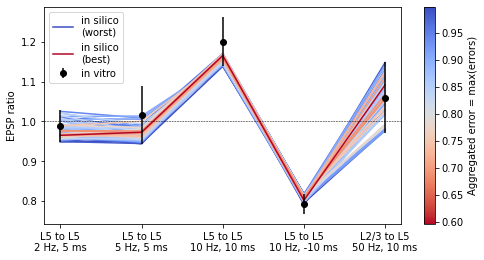

In [8]:
figsize = (4, 2) if pubstyle else (8, 4)

n, m = valid.outcome.shape

invitro_data = invitro_res[invitro_res.protocol_id.isin(valid.outcome.columns)]

norm = mpl.colors.Normalize(vmin=valid.aggerror.min(), vmax=valid.aggerror.max())
cmap = cm.coolwarm_r

sm = cm.ScalarMappable(norm=norm, cmap=cmap)

fig, ax = plt.subplots(figsize=figsize)

for i in range(n):
    if i == 0:
        label = "in silico\n(worst)"
    elif i == n-1:
        label = "in silico\n(best)"
    else:
        label = None
    ax.plot(valid.outcome.values[i], label=label,
            c=sm.to_rgba(valid.aggerror.values[i]))

ax.errorbar(invitro_data.label, invitro_data.mean_epsp_ratio, yerr=invitro_data.sem_epsp_ratio,
            fmt='o', color='k', label='in vitro', zorder=100)

plt.colorbar(sm, ax=ax, label="Aggregated error = max(errors)")

ax.axhline(1, color='k', lw=.5, ls='dashed')
ax.set_ylabel('EPSP ratio')
ax.legend()

#fig.savefig("valid_solutions_score.png", dpi=300)

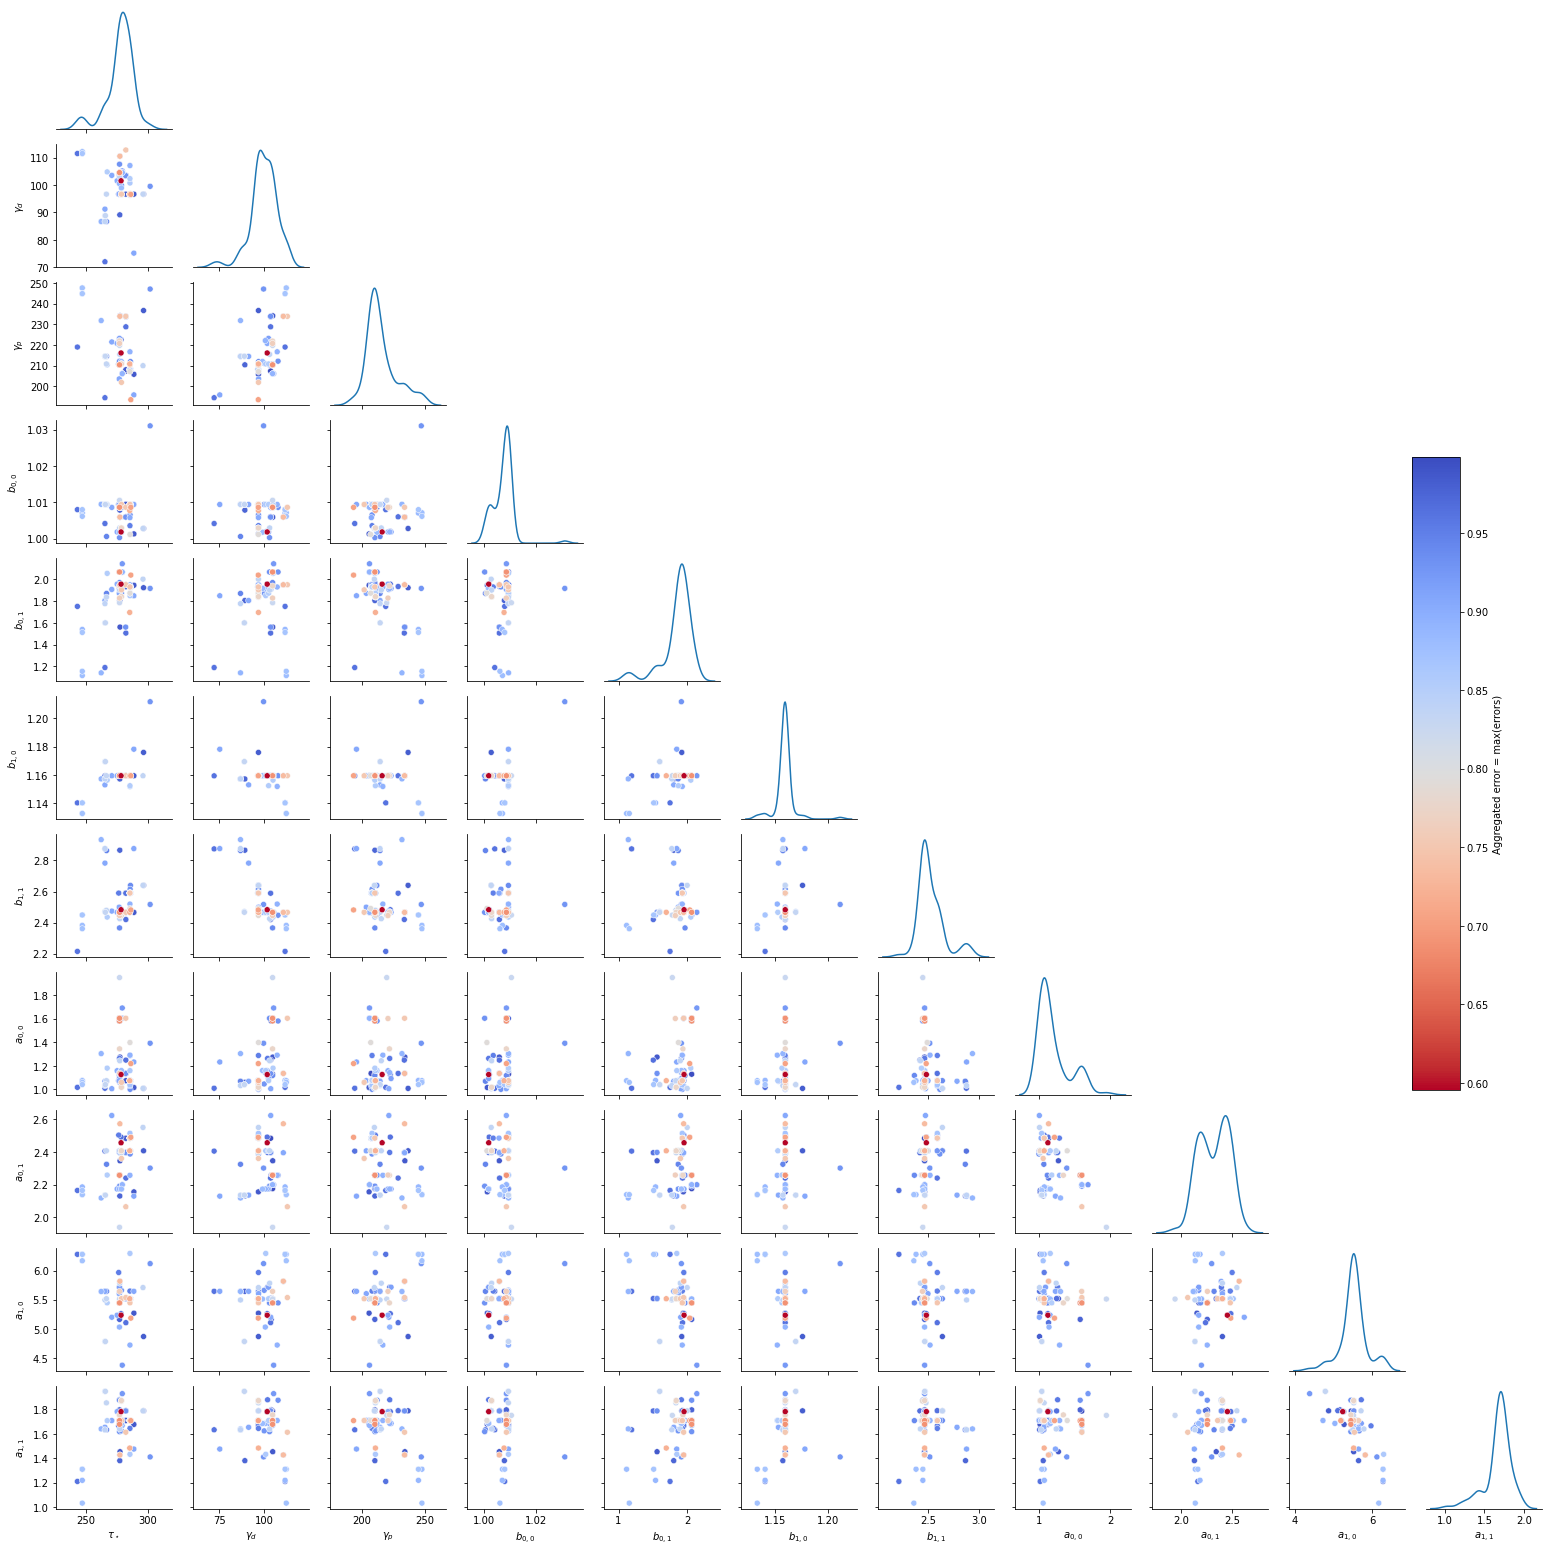

In [9]:
height = .7 if pubstyle else 2

param_df = pd.merge(valid.parameters, valid.performance, right_index=True, left_index=True)

g = sns.PairGrid(valid.parameters, diag_sharey=False, corner=True, height=height)
g.map_lower(sns.scatterplot, c=valid.aggerror.values, cmap=cmap, norm=norm)
g.map_diag(sns.kdeplot)

cax = g.figure.add_axes((.9, .3, .03, .4))

plt.colorbar(sm, cax=cax, label="Aggregated error = max(errors)")

#g.savefig("valid_solutions_params.png", dpi=300)

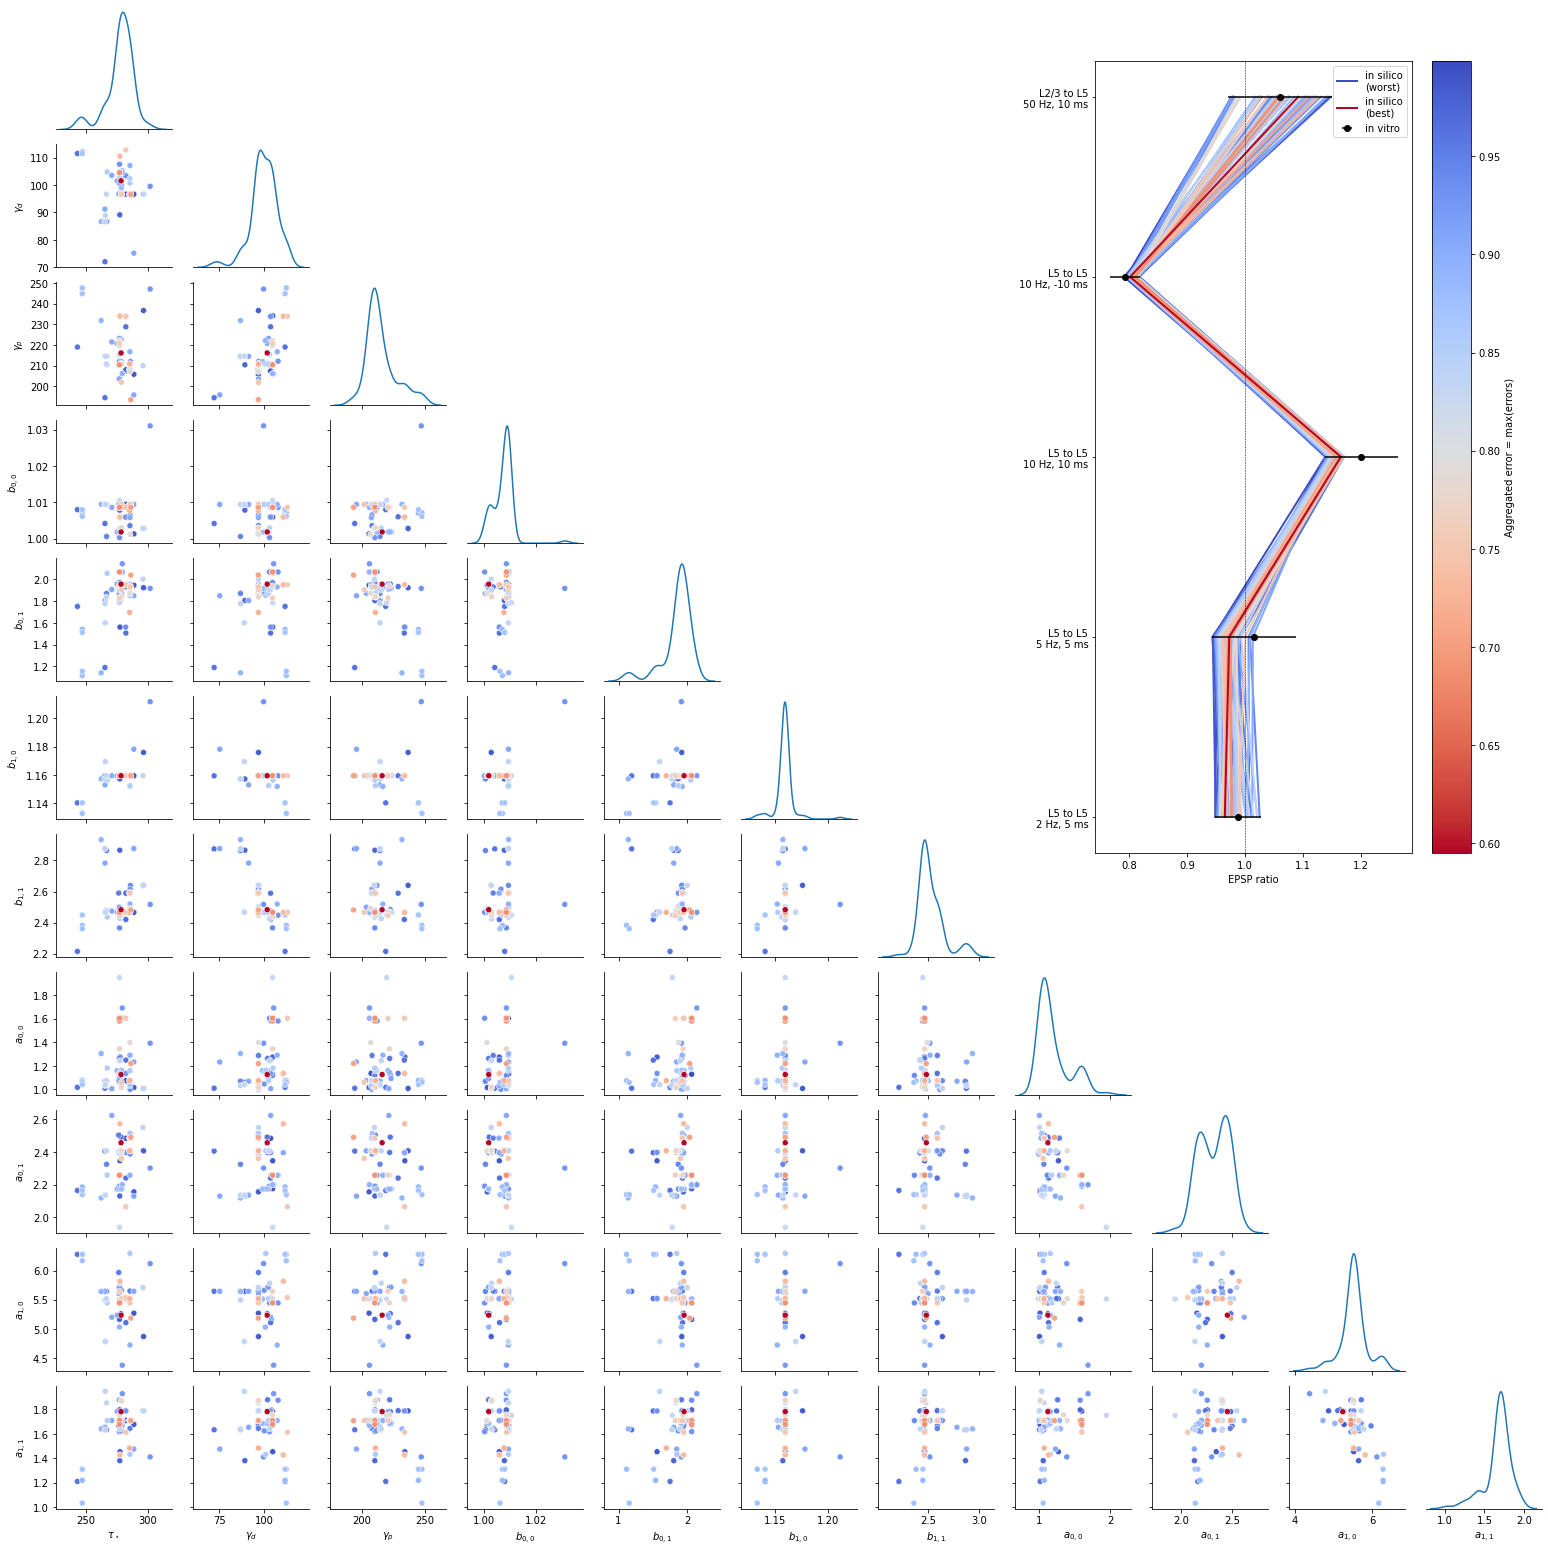

In [10]:
height = .7 if pubstyle else 2

n, m = valid.outcome.shape

invitro_data = invitro_res[invitro_res.protocol_id.isin(valid.outcome.columns)]

norm = mpl.colors.Normalize(vmin=valid.aggerror.min(), vmax=valid.aggerror.max())
cmap = cm.coolwarm_r

sm = cm.ScalarMappable(norm=norm, cmap=cmap)

param_df = pd.merge(valid.parameters, valid.performance, right_index=True, left_index=True)

g = sns.PairGrid(valid.parameters, diag_sharey=False, corner=True, height=height)
g.map_lower(sns.scatterplot, c=valid.aggerror.values, cmap=cmap, norm=norm)
g.map_diag(sns.kdeplot)

ax = g.figure.add_axes((.7, .45, .25, .5))

for i in range(n):
    if i == 0:
        label = "in silico\n(worst)"
    elif i == n-1:
        label = "in silico\n(best)"
    else:
        label = None
    ax.plot(valid.outcome.values[i], range(m), label=label,
            lw=2, c=sm.to_rgba(valid.aggerror.values[i]))

ax.errorbar(invitro_data.mean_epsp_ratio, invitro_data.label, xerr=invitro_data.sem_epsp_ratio,
            fmt='o', color='k', label='in vitro', zorder=100)

plt.colorbar(sm, ax=ax, label="Aggregated error = max(errors)")

ax.axvline(1, color='k', lw=.5, ls='dashed')
ax.set_xlabel('EPSP ratio')
ax.legend()

#g.savefig("valid_solutions.png", dpi=300)

# Best individual analysis

In [11]:
# Load best solution
best = pickle.load(open("data/insilico/best_solution_ed09b9f66b2832e2f98e760d5acf9638.pkl", "rb"))
insilico_res = best['resdb']
insilico_res

,protocol_id,epsp
0,mrk97_01,1.277082
1,mrk97_01,0.640589
2,mrk97_01,1.173178
3,mrk97_01,1.043612
4,mrk97_01,0.458127
...,...,...
495,sjh06_02,0.728392
496,sjh06_02,2.163345
497,sjh06_02,0.958240
498,sjh06_02,0.951654


In [12]:
merge_res = []
for prot_id in insilico_res.protocol_id.unique():
    # Select data
    insilico_data = insilico_res[insilico_res.protocol_id==prot_id]
    invitro_data = invitro_res[invitro_res.protocol_id==prot_id]
    # Compute stats
    insilico_mean = np.mean(insilico_data['epsp'])
    insilico_sem = stats.sem(insilico_data['epsp'])
    insilico_n = insilico_data['epsp'].count()
    insilico_std = np.std(insilico_data['epsp'])
    invitro_mean = invitro_data['mean_epsp_ratio'].values[0]
    invitro_sem = invitro_data['sem_epsp_ratio'].values[0]
    invitro_n = invitro_data['sample_size'].values[0]
    invitro_std = np.sqrt(invitro_n)*invitro_sem
    # Create label for plotting
    if invitro_data.pre_mtype.values[0] == 'L5TTPC':
        label = 'L5 to L5\n%d Hz, %d ms' % (invitro_data.frequency_train, invitro_data.dt_train)
    elif invitro_data.pre_mtype.values[0] == 'L23PC':
        label = 'L2/3 to L5\n%d Hz, %d ms' % (invitro_data.frequency_train, invitro_data.dt_train)
    else:
        raise NotImplementedError
    # One-sample t-test
    t_stat, t_p = stats.ttest_1samp(insilico_data['epsp'], invitro_mean)
    # Welch’s t-test
    wt_stat, wt_p = stats.ttest_ind_from_stats(invitro_mean, invitro_std, invitro_n,
                                               insilico_mean, insilico_std, insilico_n,
                                               equal_var=False)
    # Store entry
    merge_res.append([prot_id,
                      insilico_mean, insilico_sem, insilico_n, insilico_std,
                      invitro_mean, invitro_sem, invitro_n, invitro_std,
                      t_stat, t_p, wt_stat, wt_p, label])
merge_res = pd.DataFrame(merge_res, columns=['protocol_id',
                                             'mean_epsp_ratio_insilico', 'sem_epsp_ratio_insilico',
                                             'n_epsp_ratio_insilico', 'std_epsp_ratio_insilico',
                                             'mean_epsp_ratio_invitro', 'sem_epsp_ratio_invitro',
                                             'n_epsp_ratio_invitro', 'std_epsp_ratio_invitro',
                                             'ttest_t', 'ttest_p', 'wttest_t', 'wttest_p', 'label'])
merge_res

,protocol_id,mean_epsp_ratio_insilico,sem_epsp_ratio_insilico,n_epsp_ratio_insilico,std_epsp_ratio_insilico,mean_epsp_ratio_invitro,sem_epsp_ratio_invitro,n_epsp_ratio_invitro,std_epsp_ratio_invitro,ttest_t,ttest_p,wttest_t,wttest_p,label
0,mrk97_01,0.965226,0.033956,100,0.337856,0.9886,0.0400,2,0.056569,-0.688379,0.492824,0.446427,0.686305,"L5 to L5\n2 Hz, 5 ms"
1,mrk97_02,0.972830,0.045398,100,0.451705,1.0161,0.0727,5,0.162562,-0.953125,0.342848,0.505550,0.627434,"L5 to L5\n5 Hz, 5 ms"
2,mrk97_07,1.165866,0.050747,100,0.504925,1.2013,0.0626,6,0.153338,-0.698244,0.486661,0.440578,0.666575,"L5 to L5\n10 Hz, 10 ms"
3,mrk97_08,0.801621,0.038238,100,0.380467,0.7922,0.0259,6,0.063442,0.246381,0.805898,-0.204695,0.838839,"L5 to L5\n10 Hz, -10 ms"
4,sjh06_02,1.091966,0.069622,100,0.692732,1.0600,0.0900,19,0.392301,0.459129,0.647148,-0.281454,0.779715,"L2/3 to L5\n50 Hz, 10 ms"


Text(0.5, 0, 'EPSP ratio')

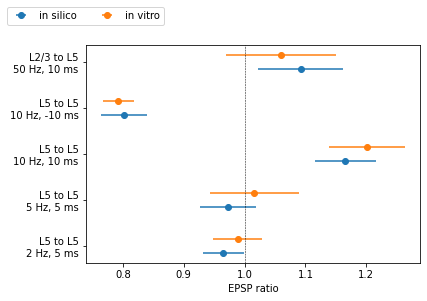

In [13]:
figsize = (1.37, 1.59) if pubstyle else None

fig, ax = plt.subplots(figsize=figsize)
trans1 = Affine2D().translate(0.0, -0.15) + ax.transData
trans2 = Affine2D().translate(0.0, +0.15) + ax.transData
ax.errorbar(merge_res.mean_epsp_ratio_insilico, merge_res.label,
            xerr=merge_res.sem_epsp_ratio_insilico,
            fmt='o', color='C0', transform=trans1, label='in silico')
ax.errorbar(merge_res.mean_epsp_ratio_invitro, merge_res.label,
            xerr=merge_res.sem_epsp_ratio_invitro,
            fmt='o', color='C1', transform=trans2, label='in vitro')
ax.legend(ncol=2, bbox_to_anchor=(0., 1.2), loc='upper center')
ax.axvline(1, color='k', lw=.5, ls='dashed')
ax.set_xlabel('EPSP ratio')
#fig.savefig('optres.svg')